# Scatter GUI - Quantum Toolkit
This notebook provides an interactive GUI for quantum scattering and eigenstate calculations using ipywidgets and quantum_toolkit.

## Imports and Style
Import all required libraries and set up notebook-wide CSS for widget display.

In [1]:
import atomic_units as au
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import quantum_toolkit as quat
import scipy.sparse as sparse
import numpy as np
import json
import deepdish as dd
import os
import threading
import time

display(HTML("""
<style>
.output_scroll {overflow: visible !important; max-height: none !important;}
.potparam-row > .widget-label { min-width: 90px; }
.potparam-row > .widget-label, .potparam-row > .widget-inline-hbox { margin-right: 8px; }
</style>
"""))

In [2]:
# Universal helper function: create a row with two input widgets and their units, plus a label at the start.
def double_input_row(
    label: str,
    unit1: str,
    unit2: str,
    value1: float = 0.0,
    value2: float = 0.0,
    label_width: str = '110px',
    input_width: str = '100px',
    unit_width: str = '40px',
    spacing: str = '0 0 2px 0'
):
    """
    Universal helper: create a row with two input widgets and their units, plus a label at the start.
    Parameters:
        label: Text label at the start of the row.
        unit1: Unit string for the first widget (e.g. '[nm]').
        unit2: Unit string for the second widget.
        value1: Initial value for the first input (default 0.0).
        value2: Initial value for the second input (default 0.0).
        label_width, input_width, unit_width: optional widths.
        spacing: row margin.
    Returns:
        (HBox, widget1, widget2): The row widget and the two input widgets.
    """
    widget1 = widgets.FloatText(value=value1, layout=widgets.Layout(width=input_width))
    widget2 = widgets.FloatText(value=value2, layout=widgets.Layout(width=input_width))
    label_widget = widgets.Label(label, layout=widgets.Layout(width=label_width))
    unit1_widget = widgets.Label(unit1, layout=widgets.Layout(width=unit_width))
    unit2_widget = widgets.Label(unit2, layout=widgets.Layout(width=unit_width))
    row = widgets.HBox(
        [label_widget, widget1, unit1_widget, widget2, unit2_widget],
        layout=widgets.Layout(margin=spacing)
    )
    return row, widget1, widget2

# Example usage:
# row, widget1, widget2 = double_input_row("Box width:", "[nm]", "[u.sys.]", value1=10.0, value2=20.0)

## Unit System
Define atomic base units and create atomic unit system.

In [3]:
# Atomic base unit parameters
hb = 1.0
m0 = 8.8
k0 = 2.3
e0 = 3.4
unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=k0)

In [4]:
# Unit system widgets
input_widget_width = '200px'
hbar_widget = widgets.FloatText(description="hbar:", value=unit_sys.hb, min=1e-10, layout=widgets.Layout(width=input_widget_width))
m0_widget = widgets.FloatText(description="m0:", value=unit_sys.me, min=1e-10, layout=widgets.Layout(width=input_widget_width))
kappa0_widget = widgets.FloatText(description="kappa0:", value=unit_sys.k0, min=1e-10, layout=widgets.Layout(width=input_widget_width))
e0_widget = widgets.FloatText(description="e0:", value=unit_sys.e0, min=1e-10, layout=widgets.Layout(width=input_widget_width))

def update_unit_info(*args):
    # Update the main units of the unit system
    length_nm = unit_sys.length_unit.to('nm').magnitude
    time_fs = unit_sys.time_unit.to('fs').magnitude
    energy_ev = unit_sys.energy_unit.to('eV').magnitude
    frequency_THz = unit_sys.frequency_unit.to('THz').magnitude
    velocity_mps = unit_sys.velocity_unit.to('m/s').magnitude
    speed_of_light = unit_sys.speed_of_light
    electric_field_GVpm = unit_sys.electric_field_unit.to('GV/m').magnitude

    unit_info_html.value = (
        f"<b>Length unit:</b> {length_nm:.6g} nm<br>"
        f"<b>Time unit:</b> {time_fs:.6g} fs<br>"
        f"<b>Energy unit:</b> {energy_ev:.6g} eV"
        f"<br><b>Frequency unit:</b> {frequency_THz:.6g} THz<br>"
        f"<b>Velocity unit:</b> {velocity_mps:.6g} m/s<br>"
        f"<b>Speed of light:</b> {speed_of_light:.6g}<br>"
        f"<b>Electric field unit:</b> {electric_field_GVpm:.6g} GV/m"
    )

def update_unit_system(change):
    """Update the atomic unit system based on widget values."""
    global unit_sys
    unit_sys = au.AtomicUnitSystem(
        xh=hbar_widget.value,
        xe=e0_widget.value,
        xm=m0_widget.value,
        xk=kappa0_widget.value
    )
    update_unit_info()

# Attach update function to widget changes
hbar_widget.observe(update_unit_system, names='value')
m0_widget.observe(update_unit_system, names='value')
kappa0_widget.observe(update_unit_system, names='value')
e0_widget.observe(update_unit_system, names='value')

unit_info_html = widgets.HTML()

# Update on any unit widget value change
for w in [hbar_widget, m0_widget, kappa0_widget, e0_widget]:
    w.observe(lambda change: update_unit_info(), names='value')

# Update on first display as well
update_unit_info()

unit_tab = widgets.VBox([
    widgets.Label("Rescaled atomic unit system [u.sys.]"),
    hbar_widget,
    m0_widget,
    kappa0_widget,
    e0_widget,
    unit_info_html  # New text with main units
])

## Grid
1D grid with unified steps 

In [5]:
# Grid initalization
uxgrid_num = 8*1024
uxgrid_width=400*unit_sys.convert_length_from('nm')
uxgrid,uxgrid_dx = np.linspace(-uxgrid_width/2, uxgrid_width/2, uxgrid_num, retstep=True)

In [6]:
# Box width input row using double_input_row
boxwidth_row, uxgrid_width_nm_widget, uxgrid_width_au_widget = double_input_row(
    "Box width:",
    "[nm]",
    "[u.sys.]",
    value1=(uxgrid_width * unit_sys.length_unit.to('nm')).magnitude,
    value2=uxgrid_width,
    label_width = '100px',
    input_width = '80px',
    unit_width = '50px'
)

uxgrid_num_widget = widgets.IntText(description="", value=uxgrid_num, min=3, layout=widgets.Layout(width='80px'))
uxgrid_num_label = widgets.Label("Num. of points:", layout=widgets.Layout(width='100px'))

# Step size
uxgrid_dx_widget = widgets.Label(value=f"{(uxgrid_dx*unit_sys.length_unit.to('nm')).magnitude:.6f} nm = {uxgrid_dx:.6f} u.sys.", layout=widgets.Layout(width='280px'))
uxgrid_dx_label = widgets.Label("Step size:", layout=widgets.Layout(width='100px'))

# Update grid when parameters change
def update_grid_tab(change):
    global uxgrid, uxgrid_dx
    src = change['owner']

    uxgrid_num = uxgrid_num_widget.value
    uxgrid_width_nm = uxgrid_width_nm_widget.value
    uxgrid_width_au = uxgrid_width_au_widget.value

    if uxgrid_num < 3:
        uxgrid_num = 3
        uxgrid_num_widget.value = 3

    if uxgrid_width_nm < 1e-10:
        uxgrid_width_nm = 1e-10
        uxgrid_width_nm_widget.value = 1e-10

    if uxgrid_width_au < 1e-10:
        uxgrid_width_au = 1e-10
        uxgrid_width_au_widget.value = 1e-10

    # Synchronization: if the nm field changed, update the a.u. field, and vice versa
    if src is uxgrid_width_nm_widget:
        new_au = uxgrid_width_nm * unit_sys.convert_length_from('nm')
        if abs(uxgrid_width_au_widget.value - new_au) > 1e-12:
            uxgrid_width_au_widget.value = new_au
        uxgrid_width_au = new_au
    elif src is uxgrid_width_au_widget:
        new_nm = uxgrid_width_au * unit_sys.length_unit.to('nm').magnitude
        if abs(uxgrid_width_nm_widget.value - new_nm) > 1e-12:
            uxgrid_width_nm_widget.value = new_nm
        uxgrid_width_nm = new_nm

    # Update grid values
    uxgrid, uxgrid_dx = np.linspace(-uxgrid_width_au/2, uxgrid_width_au/2, uxgrid_num, retstep=True)

    # Update step size label
    uxgrid_dx_widget.value = f"{(uxgrid_dx*unit_sys.length_unit.to('nm')).magnitude:.6f} [nm] = {uxgrid_dx:.6f} [u.sys.]"

uxgrid_num_widget.observe(update_grid_tab, names='value')
uxgrid_width_nm_widget.observe(update_grid_tab, names='value')
uxgrid_width_au_widget.observe(update_grid_tab, names='value')

# Create the grid tab
grid_tab = widgets.VBox([
    widgets.Label("Grid setup"),
    widgets.HBox([uxgrid_num_label, uxgrid_num_widget]),
    boxwidth_row,
    widgets.HBox([uxgrid_dx_label, uxgrid_dx_widget])
])

## Potential Parameters and Model Potential
Define widgets for potential parameters and the function to generate the model potential.

In [7]:
# Egységes input box szélesség
pot_input_width = '100px'

# Segédfüggvény: egy sorba teszi a leírást, inputot, mértékegységet
def potparam_row(label, widget, unit):
    widget.layout = widgets.Layout(width=pot_input_width)
    label_widget = widgets.Label(label, layout=widgets.Layout(width='110px'))
    unit_widget = widgets.Label(unit, layout=widgets.Layout(width='40px'))
    return widgets.HBox([label_widget, widget, unit_widget], layout=widgets.Layout(margin='0 0 2px 0'))

# Potenciál paraméter widgetek
wallwidth_widget = widgets.FloatText(value=3.0)
wallheight_widget = widgets.FloatText(value=1.0)
wallrise_widget = widgets.FloatText(value=1.0)
wellwidth_widget = widgets.FloatText(value=10.0)
welldepth_widget = widgets.FloatText(value=1.0)
wellfall_widget = widgets.FloatText(value=1.0)

# Superlattice widgetek
num_cells_widget = widgets.IntText(value=1, min=1)
cell_spacing_widget = widgets.FloatText(value=0.0)

# Paraméter sorok
wallwidth_row = potparam_row("wallwidth", wallwidth_widget, "[nm]")
wallheight_row = potparam_row("wallheight", wallheight_widget, "[eV]")
wallrise_row = potparam_row("wallrise", wallrise_widget, "[nm]")
wellwidth_row = potparam_row("wellwidth", wellwidth_widget, "[nm]")
welldepth_row = potparam_row("welldepth", welldepth_widget, "[eV]")
wellfall_row = potparam_row("wellfall", wellfall_widget, "[nm]")
num_cells_row = potparam_row("Number of cells", num_cells_widget, "")
cell_spacing_row = potparam_row("Cell spacing", cell_spacing_widget, "")

def get_modelpot():
    wallwidth = wallwidth_widget.value * unit_sys.convert_length_from('nm')
    wallheight = wallheight_widget.value * unit_sys.convert_energy_from('eV')
    wallrise = wallrise_widget.value
    wellwidth = wellwidth_widget.value * unit_sys.convert_length_from('nm')
    welldepth = welldepth_widget.value * unit_sys.convert_energy_from('eV')
    wellfall = wellfall_widget.value
    num_cells = num_cells_widget.value
    cell_spacing = cell_spacing_widget.value * unit_sys.convert_length_from('nm')

    # One cell width (2*wall + well + spacing)
    cell_length_nm = 2*wallwidth_widget.value + wellwidth_widget.value + cell_spacing_widget.value
    cell_length_unit = cell_length_nm * unit_sys.convert_length_from('nm')

    pot = np.zeros_like(uxgrid)
    for i in range(num_cells):
        offset = (i - (num_cells-1)/2) * cell_length_unit
        cell_pot = pots.SmoothStackPotential(
            uxgrid - offset,
            wallwidth=wallwidth,
            wallheight=wallheight,
            welldepth=welldepth,
            wellwidth=wellwidth,
            wallrise=wallrise,
            wellfall=wellfall
        )(0)
        pot += cell_pot
    return lambda t=0: pot

plot_unit_toggle = widgets.ToggleButtons(
    options=[('unit_sys', False), ('nm/eV', True)],
    value=True,
    description='Plot units:',
    style={'description_width': 'initial'}
)
plot_margin_widget = widgets.FloatText(value=10.0, layout=widgets.Layout(width='70px'))
plot_margin_label = widgets.Label("nm")
pot_output = widgets.Output()
pot_output.layout = widgets.Layout(overflow='visible', max_height='none')

def plot_potential(change=None):
    with pot_output:
        clear_output(wait=True)
        modelpot = get_modelpot()
        plot_margin_nm = plot_margin_widget.value
        total_width_nm = num_cells_widget.value * (2*wallwidth_widget.value + wellwidth_widget.value + cell_spacing_widget.value)
        x_min_nm = -0.5 * total_width_nm - plot_margin_nm
        x_max_nm = 0.5 * total_width_nm + plot_margin_nm

        if plot_unit_toggle.value:
            x_plot = uxgrid * unit_sys.length_unit.to('nm').magnitude
            y = modelpot(0) * unit_sys.energy_unit.to('eV').magnitude
            x_min = x_min_nm
            x_max = x_max_nm
            xlabel = "x [nm]"
            ylabel = "Potential [eV]"
        else:
            x_plot = uxgrid
            x_min = (x_min_nm / unit_sys.length_unit.to('nm').magnitude)
            x_max = (x_max_nm / unit_sys.length_unit.to('nm').magnitude)
            xlabel = "x [u.sys.]"
            ylabel = "Potential [u.sys.]"
            y = modelpot(0)

        plt.figure(figsize=(7, 3))
        plt.plot(x_plot, y)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid()
        plt.xlim([x_min, x_max])
        plt.tight_layout()
        plt.show()

for w in [
    wallwidth_widget, wallheight_widget, wallrise_widget,
    wellwidth_widget, welldepth_widget, wellfall_widget,
    plot_unit_toggle, plot_margin_widget,
    num_cells_widget, cell_spacing_widget
]:
    w.observe(plot_potential, names='value')
plot_potential()

potential_tab = widgets.VBox([
    plot_unit_toggle,
    widgets.HBox([widgets.Label("Plot margin:"), plot_margin_widget, plot_margin_label]),
    num_cells_row,
    cell_spacing_row,
    wallwidth_row,
    wallheight_row,
    wallrise_row,
    wellwidth_row,
    welldepth_row,
    wellfall_row,
    pot_output
])

## Eigenstate Calculation Tab
Widgets and logic for eigenstate calculation and plotting.

In [8]:
# Output widget for eigenstate results and plots
eigen_output = widgets.Output()

# Widgets for number of eigenvalues to compute and plot
num_eigen_widget = widgets.IntText(
    value=6, min=1, description="Number of eigenvalues to compute:",
    style={'description_width': 'initial'}
)
num_plot_widget = widgets.IntText(
    value=6, min=1, description="Number of eigenvalues to show on plot:",
    style={'description_width': 'initial'}
)

# Toggle for plot units (atomic units or nm/eV)
eigen_unit_toggle = widgets.ToggleButtons(
    options=[('unit_sys', False), ('nm/eV', True)],
    value=True,
    description='Plot units:',
    style={'description_width': 'initial'}
)

# Variables to store last computed eigenvalues and eigenvectors
eigenvalues = None
eigenvectors = None

# Function to compute eigenstates
def compute_eigenstates(_=None):
    """
    Compute the eigenvalues and eigenvectors of the Hamiltonian.
    """
    global eigenvalues, eigenvectors
    with eigen_output:
        clear_output(wait=True)
        modelpot = get_modelpot()
        zeropot = pots.ZeroPotential(uxgrid)
        ham_static = quat.HamiltonOperator(
            uxgrid,
            hbar=unit_sys.hb,
            me=unit_sys.me,
            charge=unit_sys.e0,
            scalarpot=modelpot,
            vectorpot=zeropot
        )

        num_eigen = max(1, int(num_eigen_widget.value))
        num_plot = max(1, int(num_plot_widget.value))

        print(f"Diagonalization in progress for {num_eigen} eigenvalues, please wait...")
        # Compute eigenvalues and eigenvectors using sparse diagonalization
        eigenvalues, eigenvectors = sparse.linalg.eigsh(ham_static(0), num_eigen, which='SR')
        print("Diagonalization completed.")
        plot_eigenstates(num_plot)

def plot_eigenstates(num_plot=None):
    """
    Plot the potential and the computed eigenstates.
    """
    with eigen_output:
        clear_output(wait=True)
        if eigenvalues is None:
            print("No eigenstate data. Please compute eigenstates first.")
            return
        if num_plot is None:
            num_plot = max(1, int(num_plot_widget.value))

        num_eigen = len(eigenvalues)

        # Determine plot units and prepare data
        if eigen_unit_toggle.value:
            # Plot in nm/eV
            x_plot = uxgrid * unit_sys.length_unit.to('nm').magnitude
            y_pot = get_modelpot()(0) * unit_sys.energy_unit.to('eV').magnitude
            eigenvalues_plot = eigenvalues * unit_sys.energy_unit.to('eV').magnitude
            xlabel = "x [nm]"
            ylabel = "Energy [eV]"
        else:
            # Plot in atomic units
            x_plot = uxgrid
            y_pot = get_modelpot()(0)
            eigenvalues_plot = eigenvalues
            xlabel = "x [u.sys.]"
            ylabel = "Energy [u.sys.]"

        # Plot potential and eigenenergies
        plt.figure(figsize=(8, 4))
        plt.plot(x_plot, y_pot, label="Potential")
        for eval, evec in zip(eigenvalues_plot[:num_plot], np.transpose(eigenvectors)[:num_plot]):
            plt.plot(x_plot, eval * np.ones_like(x_plot), "--", label=f"E={eval:.2e}")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xlim([x_plot[0], x_plot[-1]])
        plt.legend(loc='upper right')
        plt.grid()
        plt.title("Eigenstates and Potential")
        plt.show()

        # Plot eigenvalues as scatter
        plt.figure()
        plt.scatter(np.arange(num_eigen)[:num_plot], eigenvalues_plot[:num_plot], marker='o', color='red')
        plt.xlabel("State index")
        plt.ylabel(ylabel)
        plt.title("Eigenvalues")
        plt.grid()
        plt.show()

# Button to trigger eigenstate computation
eigen_button = widgets.Button(description="Compute", button_style='primary')
eigen_button.on_click(compute_eigenstates)

# Update plot when number of plotted eigenstates or unit toggle changes
num_plot_widget.observe(lambda change: plot_eigenstates(), names='value')
eigen_unit_toggle.observe(lambda change: plot_eigenstates(), names='value')

# Photon wavelength input and calculated photon energy display
photon_wavelength_widget = widgets.FloatText(
    value=800.0, description="Photon wavelength [nm]:", style={'description_width': 'initial'}
)
photon_energy_widget = widgets.Label(value="Photon energy: --- eV")

def update_photon_energy(change=None):
    """
    Update the photon energy label based on the wavelength.
    """
    # E = hc/λ, h = 4.135667696e-15 eV·s, c = 299792458 m/s, λ in nm
    h = 4.135667696e-15  # eV·s
    c = 299792458  # m/s
    try:
        wavelength_nm = photon_wavelength_widget.value
        wavelength_m = wavelength_nm * 1e-9
        energy_eV = h * c / wavelength_m
        photon_energy_widget.value = f"Photon energy: {energy_eV:.3f} eV"
    except Exception:
        photon_energy_widget.value = "Photon energy: --- eV"

photon_wavelength_widget.observe(update_photon_energy, names='value')
update_photon_energy()

# Unified layout for Eigenstates tab
eigen_label_width = '200px'
eigen_input_width = '300px'

num_eigen_widget.layout = widgets.Layout(width=eigen_input_width)
num_plot_widget.layout = widgets.Layout(width=eigen_input_width)
photon_wavelength_widget.layout = widgets.Layout(width=eigen_input_width)

def eigen_row(label, widget):
    label_widget = widgets.Label(label, layout=widgets.Layout(width=eigen_label_width))
    return widgets.HBox([label_widget, widget], layout=widgets.Layout(margin='0 0 2px 0'))

# Assemble the Eigenstates tab layout
eigen_tab = widgets.VBox([
    widgets.Label("Eigenstate calculation"),
    eigen_unit_toggle,
    widgets.VBox([
        num_eigen_widget,
        num_plot_widget,
        photon_wavelength_widget,
        widgets.HBox([widgets.Label("", layout=widgets.Layout(width=eigen_label_width)), photon_energy_widget]),
    ], layout=widgets.Layout(align_items='flex-start', width='370px')),
    widgets.HBox([eigen_button]),
    eigen_output
])

## Dispersion Visualization Tab
Interactive plot for dispersion k grid setup.

In [9]:
# Dispersion object and update logic
dispersion = None
def update_dispersion(*args):
    global dispersion
    try:
        dispersion = quat.CosineDispersion(
            uxgrid_dx,
            hbar=hbar_widget.value,
            mass=m0_widget.value
        )
    except Exception as e:
        print("Error creating dispersion:", e)
update_dispersion()

uxgrid_dx_widget.observe(lambda change: update_dispersion(), names='value')
hbar_widget.observe(lambda change: update_dispersion(), names='value')
m0_widget.observe(lambda change: update_dispersion(), names='value')

# Output widget placeholder for the plot
disp_output = widgets.Output()

disp_grid_mode = widgets.Dropdown(
    options=['unified in energy', 'unified in k'],
    value='unified in k',
    description='Grid type:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='180px')
)

# Use double_input_row helper for min/max energy fields, each row for min and max separately
disp_energy_min_row, disp_energy_min_ev, disp_energy_min_au = double_input_row(
    label="Energy min:",
    unit1="[eV]",
    unit2="[u.sys.]",
    value1=0.02,
    value2=0.02 * unit_sys.convert_energy_from('eV'),
    label_width='90px',
    input_width='80px',
    unit_width='50px'
)
disp_energy_max_row, disp_energy_max_ev, disp_energy_max_au = double_input_row(
    label="Energy max:",
    unit1="[eV]",
    unit2="[u.sys.]",
    value1=1.2,
    value2=1.2 * unit_sys.convert_energy_from('eV'),
    label_width='90px',
    input_width='80px',
    unit_width='50px'
)

disp_number_of_points = widgets.IntText(
    value=50,
    min=1,
    description='Num. of pts.:',
    layout=widgets.Layout(width='180px')
)

def sync_disp_energy_min_ev(change):
    try:
        new_ev = disp_energy_min_ev.value
        new_au = new_ev * unit_sys.convert_energy_from('eV')
        if abs(disp_energy_min_au.value - new_au) > 1e-12:
            disp_energy_min_au.value = new_au
    except Exception:
        pass

def sync_disp_energy_min_au(change):
    try:
        new_au = disp_energy_min_au.value
        new_ev = new_au * unit_sys.energy_unit.to('eV').magnitude
        if abs(disp_energy_min_ev.value - new_ev) > 1e-12:
            disp_energy_min_ev.value = new_ev
    except Exception:
        pass

def sync_disp_energy_max_ev(change):
    try:
        new_ev = disp_energy_max_ev.value
        new_au = new_ev * unit_sys.convert_energy_from('eV')
        if abs(disp_energy_max_au.value - new_au) > 1e-12:
            disp_energy_max_au.value = new_au
    except Exception:
        pass

def sync_disp_energy_max_au(change):
    try:
        new_au = disp_energy_max_au.value
        new_ev = new_au * unit_sys.energy_unit.to('eV').magnitude
        if abs(disp_energy_max_ev.value - new_ev) > 1e-12:
            disp_energy_max_ev.value = new_ev
    except Exception:
        pass

disp_energy_min_ev.observe(sync_disp_energy_min_ev, names='value')
disp_energy_min_au.observe(sync_disp_energy_min_au, names='value')
disp_energy_max_ev.observe(sync_disp_energy_max_ev, names='value')
disp_energy_max_au.observe(sync_disp_energy_max_au, names='value')

disp_plot_unit_toggle = widgets.ToggleButtons(
    options=[('unit_sys', False), ('nm/eV', True)],
    value=True,
    description='Plot units:',
    style={'description_width': 'initial'}
)

def update_dispersion_grid(change=None):
    """
    Update the dispersion grid plot based on the current parameters.
    """
    with disp_output:
        clear_output(wait=True)
        # Get parameters
        grid_mode = disp_grid_mode.value
        energy_min = disp_energy_min_au.value
        energy_max = disp_energy_max_au.value
        num_points = disp_number_of_points.value

        if energy_min >= energy_max:
            print("Error: Minimum energy must be less than maximum energy.")
            return

        # Create the dispersion grid
        if grid_mode == 'unified in energy':
            e_values = np.linspace(energy_min, energy_max, num_points)
            k_values = dispersion.wavenumber(e_values)
        else:
            k_min = dispersion.wavenumber(energy_min)
            k_max = dispersion.wavenumber(energy_max)
            k_values = np.linspace(k_min, k_max, num_points)
            e_values = dispersion.energy(k_values)

        # Plot the dispersion grid
        if disp_plot_unit_toggle.value:
            k_plot = k_values * unit_sys.length_unit.to('nm').magnitude
            e_plot = e_values * unit_sys.energy_unit.to('eV').magnitude
            xlabel = "k [1/nm]"
            ylabel = "Energy [eV]"
        else:
            k_plot = k_values
            e_plot = e_values
            xlabel = "k [u.sys.]"
            ylabel = "Energy [u.sys.]"

        # Explicit tengelyhatárok + padding
        k_min_plot = np.min(k_plot)
        k_max_plot = np.max(k_plot)
        e_min_plot = np.min(e_plot)
        e_max_plot = np.max(e_plot)
        # Padding: 5% a tartományból
        k_pad = (k_max_plot - k_min_plot) * 0.05 if k_max_plot > k_min_plot else 1.0
        e_pad = (e_max_plot - e_min_plot) * 0.05 if e_max_plot > e_min_plot else 1.0

        plt.scatter(k_plot, e_plot, color='black', marker='o', label='E(k) points')
        plt.scatter(k_plot, np.full_like(k_plot, e_min_plot), color='red', marker='|', s=100, label='k points')
        plt.scatter(np.full_like(e_plot, k_min_plot), e_plot, color='blue', marker='_', s=100, label='E points')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xlim([k_min_plot - k_pad, k_max_plot + k_pad])
        plt.ylim([e_min_plot - e_pad, e_max_plot + e_pad])
        plt.grid()
        plt.legend()
        plt.show()

dispersion_tab = widgets.VBox([
    disp_grid_mode,
    disp_energy_min_row,
    disp_energy_max_row,
    disp_number_of_points,
    disp_plot_unit_toggle,
    disp_output
])

# Csak az [eV] mezőhöz rendeljük hozzá az update-et, az [u.sys.]-hez nem!
disp_grid_mode.observe(update_dispersion_grid, names='value')
disp_energy_min_ev.observe(update_dispersion_grid, names='value')
disp_energy_max_ev.observe(update_dispersion_grid, names='value')
disp_number_of_points.observe(update_dispersion_grid, names='value')
disp_plot_unit_toggle.observe(update_dispersion_grid, names='value')

# Első megjelenítés
# update_dispersion_grid()

## Scatter Tab
A Scatter tabban a Dispersion tabban generált energia-k párok listája jelenik meg. A felhasználó kiválaszthatja, mely pontokat szeretné használni, és a kiválasztott pontokat egy ábra is megjeleníti.

In [10]:
# Scatter tab: energia-k párok listája, kiválasztás, és ábra
quasiparticles_pk = []
quasiparticles_mk = []

from ipywidgets import SelectMultiple, VBox, HBox, Label, Output, Layout

# Segédfüggvény: lekéri az aktuális dispersion grid energia-k párokat
def get_dispersion_points():
    grid_mode = disp_grid_mode.value
    energy_min = disp_energy_min_au.value
    energy_max = disp_energy_max_au.value
    num_points = disp_number_of_points.value
    if energy_min >= energy_max or num_points < 1:
        return np.array([]), np.array([])
    if grid_mode == 'unified in energy':
        e_values = np.linspace(energy_min, energy_max, num_points)
        k_values = dispersion.wavenumber(e_values)
    else:
        k_min = dispersion.wavenumber(energy_min)
        k_max = dispersion.wavenumber(energy_max)
        k_values = np.linspace(k_min, k_max, num_points)
        e_values = dispersion.energy(k_values)
    return np.array(e_values), np.array(k_values)

# Lista widget: minden pont (index, energia, k)
def make_scatter_options():
    e_values, k_values = get_dispersion_points()
    options = []
    for i, (e, k) in enumerate(zip(e_values, k_values)):
        # nm/eV egységben jelenítjük meg
        e_ev = e * unit_sys.energy_unit.to('eV').magnitude
        k_nm = k * unit_sys.length_unit.to('nm').magnitude
        label = f"{i}: E={e_ev:.3f} eV, k={k_nm:.3f} 1/nm"
        options.append((label, i))
    return options

scatter_options = make_scatter_options()
scatter_select = SelectMultiple(
    options=scatter_options,
    value=tuple(i for _, i in scatter_options),  # alapból minden kiválasztva
    rows=10,
    description='Points:',
    layout=Layout(width='350px', height='220px')
)

scatter_plot_output = Output(layout=Layout(width='350px', height='220px'))

def update_scatter_options(*args):
    scatter_select.options = make_scatter_options()
    scatter_select.value = tuple(i for _, i in scatter_select.options)
    update_scatter_plot()

def update_scatter_plot(*args):
    with scatter_plot_output:
        clear_output(wait=True)
        e_values, k_values = get_dispersion_points()
        selected_indices = scatter_select.value
        if len(e_values) == 0 or len(selected_indices) == 0:
            print("Nincs kijelölt pont.")
            return
        # nm/eV egységben ábrázoljuk
        e_ev = e_values[list(selected_indices)] * unit_sys.energy_unit.to('eV').magnitude
        k_nm = k_values[list(selected_indices)] * unit_sys.length_unit.to('nm').magnitude
        plt.figure(figsize=(4, 3))
        plt.scatter(k_nm, e_ev, color='red', label='Kiválasztott pontok')
        plt.xlabel("k [1/nm]")
        plt.ylabel("E [eV]")
        #plt.title("Kiválasztott energia-k pontok")
        plt.grid()
        plt.tight_layout()
        plt.show()

# Frissítsük a listát és ábrát, ha a dispersion grid változik
disp_grid_mode.observe(update_scatter_options, names='value')
disp_energy_min_ev.observe(update_scatter_options, names='value')
disp_energy_max_ev.observe(update_scatter_options, names='value')
disp_number_of_points.observe(update_scatter_options, names='value')
disp_plot_unit_toggle.observe(update_scatter_options, names='value')
scatter_select.observe(update_scatter_plot, names='value')

scatter_progress = widgets.IntProgress(
    value=0, min=0, max=1, description='Progress:', bar_style='', orientation='horizontal',
    layout=Layout(width='350px')
)

# Gomb a scatter plot frissítéséhez
scatter_tab_compute_button = widgets.Button(
    description="Compute quasi-particles",
    button_style='primary',
    layout=Layout(width='200px')
)

scatter_thread = None
scatter_stop_event = threading.Event()

def scatter_compute_worker(selected_indices, e_values, k_values):
    global quasiparticles_pk, quasiparticles_mk, scatter_thread
    quasiparticles_pk.clear()
    quasiparticles_mk.clear()
    scatter_progress.max = len(selected_indices)
    scatter_progress.value = 0
    scatter_tab_compute_button.description = "Stop"
    scatter_tab_compute_button.button_style = 'danger'
    scatter_tab_compute_button.icon = 'stop'

    modelpot = get_modelpot()
    zeropot = pots.ZeroPotential(uxgrid)
    ham_static = quat.HamiltonOperator(
        uxgrid,
        hbar=unit_sys.hb,
        me=unit_sys.me,
        charge=unit_sys.e0,
        scalarpot=modelpot,
        vectorpot=zeropot
    )

    for idx, i in enumerate(selected_indices):
        if scatter_stop_event.is_set():
            break
        ein = e_values[i]
        kin = k_values[i]

        qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein, kin, ham_static, fit_num=50)
        quasiparticles_pk.append(qp_pk)
        quasiparticles_mk.append(qp_mk)

        scatter_progress.value = idx + 1
        time.sleep(0.01)  # hogy a progressbar frissüljön
    
    scatter_tab_compute_button.description = "Compute quasi-particles"
    scatter_tab_compute_button.button_style = 'primary'
    scatter_tab_compute_button.icon = ''
    scatter_thread = None
    #scatter_progress.value = 0

def scatter_tab_compute_button_clicked(btn):
    global scatter_thread, scatter_stop_event
    if scatter_thread is not None and scatter_thread.is_alive():
        # Stop kérése
        scatter_stop_event.set()
        scatter_tab_compute_button.description = "Stopping..."
        scatter_tab_compute_button.button_style = 'warning'
        return
    # Előkészítés
    e_values, k_values = get_dispersion_points()
    selected_indices = list(scatter_select.value)
    if len(selected_indices) == 0:
        return
    scatter_stop_event.clear()
    scatter_progress.max = len(selected_indices)
    scatter_progress.value = 0
    # Számítás szál indítása
    scatter_thread = threading.Thread(
        target=scatter_compute_worker,
        args=(selected_indices, e_values, k_values),
        daemon=True
    )
    scatter_thread.start()
    scatter_tab_compute_button.description = "Stop"
    scatter_tab_compute_button.button_style = 'danger'
    scatter_tab_compute_button.icon = 'stop'

scatter_tab_compute_button.on_click(scatter_tab_compute_button_clicked)

scatter_tab =VBox([
    HBox([
    scatter_select,
    scatter_plot_output]),
    scatter_tab_compute_button,
    scatter_progress
])

In [ ]:
# Új tab: Quasiparticle transmission/reflection plot
import matplotlib.pyplot as plt
from ipywidgets import Output, VBox, HBox, ToggleButtons, Label

tr_plot_output = Output()
tr_plot_output_mk = Output()
tr_plot_mode = ToggleButtons(
    options=[('k', 'k'), ('energy', 'energy')],
    value='k',
    description='X axis:',
    style={'description_width': 'initial'}
)

def plot_tr_transmission_reflection(change=None):
    with tr_plot_output:
        qp_pk = quasiparticles_pk
        if not qp_pk or len(qp_pk) == 0:
            tr_plot_output.clear_output()
            print("Nincs elérhető quasiparticle adat. Számítsd ki előbb a Scatter fülön!")
            return
        tr_plot_output.clear_output()
        # x tengely: energy vagy k
        if tr_plot_mode.value == 'k':
            x_vals = [qp.get('wavenumber', 0) * unit_sys.length_unit.to('nm').magnitude for qp in qp_pk]
            x_label = "k [1/nm]"
        else:
            x_vals = [qp.get('energy', 0) * unit_sys.energy_unit.to('eV').magnitude for qp in qp_pk]
            x_label = "Energy [eV]"
        t_vals = [qp.get('transmission', 0) for qp in qp_pk]
        r_vals = [qp.get('reflection', 0) for qp in qp_pk]
        plt.figure(figsize=(7, 3))
        plt.plot(x_vals, t_vals, '-o', label='Transmission')
        plt.plot(x_vals, r_vals, '-o', label='Reflection')
        plt.xlabel(x_label)
        plt.ylabel("Coefficient")
        plt.title("Transmission/Reflection (+k)")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()
    with tr_plot_output_mk:
        qp_mk = quasiparticles_mk
        if not qp_mk or len(qp_mk) == 0:
            tr_plot_output_mk.clear_output()
            print("Nincs elérhető quasiparticle adat. Számítsd ki előbb a Scatter fülön!")
            return
        tr_plot_output_mk.clear_output()
        if tr_plot_mode.value == 'k':
            x_vals = [qp.get('wavenumber', 0) * unit_sys.length_unit.to('nm').magnitude for qp in qp_mk]
            x_label = "k [1/nm]"
        else:
            x_vals = [qp.get('energy', 0) * unit_sys.energy_unit.to('eV').magnitude for qp in qp_mk]
            x_label = "Energy [eV]"
        t_vals = [qp.get('transmission', 0) for qp in qp_mk]
        r_vals = [qp.get('reflection', 0) for qp in qp_mk]
        plt.figure(figsize=(7, 3))
        plt.plot(x_vals, t_vals, '-o', label='Transmission')
        plt.plot(x_vals, r_vals, '-o', label='Reflection')
        plt.xlabel(x_label)
        plt.ylabel("Coefficient")
        plt.title("Transmission/Reflection (-k)")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

tr_plot_mode.observe(plot_tr_transmission_reflection, names='value')
plot_tr_transmission_reflection()

tr_plot_tab = VBox([
    Label("TR Plot (quasiparticle transmission/reflection)"),
    tr_plot_mode,
    tr_plot_output,
    tr_plot_output_mk
])

### Files tab
The "Files" tab allows you to save and load settings to/from an HDF5 file.
Set the directory and file name, then use the "Save" or "Load" buttons to store or restore your configuration.

In [12]:
if not hasattr(np, "object"):
    np.object = object

directory_widget = widgets.Text(
    value=os.getcwd(),
    description="Directory:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
filename_widget = widgets.Text(
    value="scatter_gui_data2.h5",
    description="File name:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

def get_hdf5_path():
    return os.path.join(directory_widget.value, filename_widget.value)

save_hdf5_button = widgets.Button(description="Save", button_style='success')
load_hdf5_button = widgets.Button(description="Load", button_style='warning')

files_status_html = widgets.HTML(value="")

def load_from_hdf5(btn):
    global uxgrid, eigenvalues, eigenvectors
    global quasiparticles_pk, quasiparticles_mk  # hozzáadva
    path = get_hdf5_path()
    try:
        if os.path.exists(path):
            data = dd.io.load(path)
            hbar_widget.value = data['unit_sys']['hb']
            m0_widget.value = data['unit_sys']['m0']
            kappa0_widget.value = data['unit_sys']['k0']
            e0_widget.value = data['unit_sys']['e0']
            update_unit_system({'owner': hbar_widget})  # Update unit system based on loaded values

            # uxgrid visszaállítása közvetlenül a fájlból
            uxgrid = data['grid']['uxgrid']
            uxgrid_num_widget.value = data['grid']['num']
            uxgrid_width_nm_widget.value = data['grid']['width_nm']
            uxgrid_width_au_widget.value = data['grid']['width_au']

            update_grid_tab({'owner': uxgrid_num_widget})  # Update grid based on loaded values

            # Potenciál paraméterek visszaállítása
            wallwidth_widget.value = data['potential']['wallwidth']
            wallheight_widget.value = data['potential']['wallheight']
            wallrise_widget.value = data['potential']['wallrise']
            wellwidth_widget.value = data['potential']['wellwidth']
            welldepth_widget.value = data['potential']['welldepth']
            wellfall_widget.value = data['potential']['wellfall']
            num_cells_widget.value = data['potential']['num_cells']
            cell_spacing_widget.value = data['potential']['cell_spacing']

            plot_potential()

            # Eigenstate paraméterek visszaállítása
            eigen_unit_toggle.value = data['eigenstates']['unit_sys']
            num_eigen_widget.value = data['eigenstates']['num_eigen']
            num_plot_widget.value = data['eigenstates']['num_plot']
            photon_wavelength_widget.value = data['eigenstates']['photon_wavelength']

            update_photon_energy()

            # Eigenstate adatok visszatöltése, ha vannak
            eigenvalues = None
            eigenvectors = None
            if 'eigenstates' in data:
                eigenvalues = data['eigenstates'].get('values', None)
                eigenvectors = data['eigenstates'].get('vectors', None)
                if eigenvalues is not None and eigenvectors is not None:
                    plot_eigenstates(num_plot_widget.value)
            # Dispersion tab paraméterek visszaállítása
            disp = data['dispersion']
            disp_grid_mode.value = disp.get('grid_mode', disp_grid_mode.value)
            disp_energy_min_ev.value = disp.get('energy_min_ev', disp_energy_min_ev.value)
            disp_energy_min_au.value = disp.get('energy_min_au', disp_energy_min_au.value)
            disp_energy_max_ev.value = disp.get('energy_max_ev', disp_energy_max_ev.value)
            disp_energy_max_au.value = disp.get('energy_max_au', disp_energy_max_au.value)
            disp_number_of_points.value = disp.get('number_of_points', disp_number_of_points.value)
            disp_plot_unit_toggle.value = disp.get('plot_unit_toggle', disp_plot_unit_toggle.value)
            # Frissítsd a dispersion plotot is
            update_dispersion_grid()

            # Quasi-particle adatok visszatöltése (mindig, akár üres is lehet)
            quasiparticles = data.get('quasiparticles', {})
            quasiparticles_pk = list(quasiparticles.get('pk', []))
            quasiparticles_mk = list(quasiparticles.get('mk', []))

            files_status_html.value = f"<span style='color:green'>Sikeres betöltés: {path}</span>"
        else:
            files_status_html.value = f"<span style='color:red'>A fájl nem található: {path}</span>"
    except Exception as e:
        files_status_html.value = f"<span style='color:red'>Hiba betöltés közben: {str(e)}</span>"

def save_to_hdf5(btn):
    global eigenvalues, eigenvectors
    global quasiparticles_pk, quasiparticles_mk  # hozzáadva
    path = get_hdf5_path()
    try:
        modelpot = get_modelpot()
        modelpot_values = modelpot(0)
        data = {
            "unit_sys": {
                "hb": hbar_widget.value,
                "m0": m0_widget.value,
                "k0": kappa0_widget.value,
                "e0": e0_widget.value
            },
            "grid": {
                "num": uxgrid_num_widget.value,
                "width_nm": uxgrid_width_nm_widget.value,
                "width_au": uxgrid_width_au_widget.value,
                "uxgrid": uxgrid
            },
            "potential": {
                "wallwidth": wallwidth_widget.value,
                "wallheight": wallheight_widget.value,
                "wallrise": wallrise_widget.value,
                "wellwidth": wellwidth_widget.value,
                "welldepth": welldepth_widget.value,
                "wellfall": wellfall_widget.value,
                "num_cells": num_cells_widget.value,
                "cell_spacing": cell_spacing_widget.value,
                "values": modelpot_values
            },
            "eigenstates": {
                "unit_sys": eigen_unit_toggle.value,
                "num_eigen": num_eigen_widget.value,
                "num_plot": num_plot_widget.value,
                "photon_wavelength": photon_wavelength_widget.value,
                "values": np.array(eigenvalues) if eigenvalues is not None else None,
                "vectors": np.array(eigenvectors) if eigenvectors is not None else None
            },
            "dispersion": {
                "grid_mode": disp_grid_mode.value,
                "energy_min_ev": disp_energy_min_ev.value,
                "energy_min_au": disp_energy_min_au.value,
                "energy_max_ev": disp_energy_max_ev.value,
                "energy_max_au": disp_energy_max_au.value,
                "number_of_points": disp_number_of_points.value,
                "plot_unit_toggle": disp_plot_unit_toggle.value
            },
            "quasiparticles": {
                "pk": quasiparticles_pk,
                "mk": quasiparticles_mk
            }
        }
        dd.io.save(path, data)
        files_status_html.value = f"<span style='color:green'>Sikeres mentés: {path}</span>"
    except Exception as e:
        files_status_html.value = f"<span style='color:red'>Hiba mentés közben: {str(e)}</span>"

save_hdf5_button.on_click(save_to_hdf5)
load_hdf5_button.on_click(load_from_hdf5)

files_tab = widgets.VBox([
    directory_widget,
    filename_widget,
    widgets.HBox([save_hdf5_button, load_hdf5_button]),
    files_status_html
])

/tmp/ipykernel_2040423/298623259.py:1: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Temp file for store settings

In [13]:
SETTINGS_FILE = "/tmp/scatter_gui_settings.json"

def save_settings_to_file():
    settings = {
        "unit_sys": {
            "hbar": hbar_widget.value,
            "m0": m0_widget.value,
            "kappa0": kappa0_widget.value,
            "e0": e0_widget.value,
        },
        "grid": {
            "num": uxgrid_num_widget.value,
            "width_nm": uxgrid_width_nm_widget.value,
            "width_au": uxgrid_width_au_widget.value,
        },
        "potential": {
            "wallwidth": wallwidth_widget.value,
            "wallheight": wallheight_widget.value,
            "wallrise": wallrise_widget.value,
            "wellwidth": wellwidth_widget.value,
            "welldepth": welldepth_widget.value,
            "wellfall": wellfall_widget.value,
            "num_cells": num_cells_widget.value,
            "cell_spacing": cell_spacing_widget.value
        },
        "eigenstates": {
            "num_eigen": num_eigen_widget.value,
            "num_plot": num_plot_widget.value,
            "photon_wavelength": photon_wavelength_widget.value,
            "unit_toggle": eigen_unit_toggle.value
        },
        "dispersion": {
            "grid_mode": disp_grid_mode.value,
            "energy_min_ev": disp_energy_min_ev.value,
            "energy_min_au": disp_energy_min_au.value,
            "energy_max_ev": disp_energy_max_ev.value,
            "energy_max_au": disp_energy_max_au.value,
            "number_of_points": disp_number_of_points.value,
            "plot_unit_toggle": disp_plot_unit_toggle.value
        },
        # Új: Files tab paraméterek
        "files": {
            "directory": directory_widget.value,
            "filename": filename_widget.value
        }
    }
    with open(SETTINGS_FILE, 'w') as f:
        json.dump(settings, f, indent=4)

def load_settings_from_file():
    try:
        with open(SETTINGS_FILE, 'r') as f:
            settings = json.load(f)
            # Új struktúra szerinti visszatöltés
            unit_sys_settings = settings.get("unit_sys", {})
            grid_settings = settings.get("grid", {})
            potential_settings = settings.get("potential", {})
            eigenstates_settings = settings.get("eigenstates", {})
            dispersion_settings = settings.get("dispersion", {})
            # Új: Files tab paraméterek visszatöltése
            files_settings = settings.get("files", {})

            hbar_widget.value = unit_sys_settings.get("hbar", unit_sys.hb)
            m0_widget.value = unit_sys_settings.get("m0", unit_sys.me)
            kappa0_widget.value = unit_sys_settings.get("kappa0", unit_sys.k0)
            e0_widget.value = unit_sys_settings.get("e0", unit_sys.e0)

            uxgrid_num_widget.value = grid_settings.get("num", uxgrid_num)
            uxgrid_width_nm_widget.value = grid_settings.get("width_nm", (uxgrid_width * unit_sys.length_unit.to('nm')).magnitude)
            uxgrid_width_au_widget.value = grid_settings.get("width_au", uxgrid_width)

            wallwidth_widget.value = potential_settings.get("wallwidth", wallwidth_widget.value)
            wallheight_widget.value = potential_settings.get("wallheight", wallheight_widget.value)
            wallrise_widget.value = potential_settings.get("wallrise", wallrise_widget.value)
            wellwidth_widget.value = potential_settings.get("wellwidth", wellwidth_widget.value)
            welldepth_widget.value = potential_settings.get("welldepth", welldepth_widget.value)
            wellfall_widget.value = potential_settings.get("wellfall", wellfall_widget.value)
            num_cells_widget.value = potential_settings.get("num_cells", num_cells_widget.value)
            cell_spacing_widget.value = potential_settings.get("cell_spacing", cell_spacing_widget.value)

            # Eigenstates tab visszatöltése
            num_eigen_widget.value = eigenstates_settings.get("num_eigen", num_eigen_widget.value)
            num_plot_widget.value = eigenstates_settings.get("num_plot", num_plot_widget.value)
            photon_wavelength_widget.value = eigenstates_settings.get("photon_wavelength", photon_wavelength_widget.value)
            eigen_unit_toggle.value = eigenstates_settings.get("unit_toggle", eigen_unit_toggle.value)

            # Dispersion tab visszatöltése
            disp_grid_mode.value = dispersion_settings.get("grid_mode", disp_grid_mode.value)
            disp_energy_min_ev.value = dispersion_settings.get("energy_min_ev", disp_energy_min_ev.value)
            disp_energy_min_au.value = dispersion_settings.get("energy_min_au", disp_energy_min_au.value)
            disp_energy_max_ev.value = dispersion_settings.get("energy_max_ev", disp_energy_max_ev.value)
            disp_energy_max_au.value = dispersion_settings.get("energy_max_au", disp_energy_max_au.value)
            disp_number_of_points.value = dispersion_settings.get("number_of_points", disp_number_of_points.value)
            disp_plot_unit_toggle.value = dispersion_settings.get("plot_unit_toggle", disp_plot_unit_toggle.value)
            # Új: Files tab paraméterek visszatöltése
            directory_widget.value = files_settings.get("directory", directory_widget.value)
            filename_widget.value = files_settings.get("filename", filename_widget.value)
    except FileNotFoundError:
        pass  # Ignore if the file does not exist
# Load settings on startup
load_settings_from_file()

# Save settings when any parameter changes
for w in [
    hbar_widget, m0_widget, kappa0_widget, e0_widget,
    uxgrid_num_widget, uxgrid_width_nm_widget, uxgrid_width_au_widget,
    wallwidth_widget, wallheight_widget, wallrise_widget,
    wellwidth_widget, welldepth_widget, wellfall_widget,
    num_cells_widget, cell_spacing_widget,
    plot_margin_widget, plot_unit_toggle,
    # Új: Eigenstates tab fő widgetjei
    num_eigen_widget, num_plot_widget, photon_wavelength_widget, eigen_unit_toggle,
    disp_grid_mode, disp_energy_min_ev, disp_energy_min_au, disp_energy_max_ev, disp_energy_max_au,
    disp_number_of_points, disp_plot_unit_toggle,
    # Új: Files tab widgetjei
    directory_widget, filename_widget
]:
    w.observe(lambda change: save_settings_to_file(), names='value')

In [ ]:
tabs = widgets.Tab(children=[
    unit_tab, grid_tab, potential_tab, eigen_tab, dispersion_tab, scatter_tab, tr_plot_tab, files_tab
])
tab_titles = [
    'Unit system', 'Grid', 'Potential', 'Eigenstates', 'Dispersion', 'Scatter', 'TR Plot', 'Files'
]
for i, title in enumerate(tab_titles):
    tabs.set_title(i, title)

def on_tab_change(change):
    # Ha a Potential tabra váltunk (index 2), frissítsük az ábrát
    if change['name'] == 'selected_index' and change['new'] == 2:
        plot_potential()
    # Ha a Dispersion tabra váltunk (index 4), frissítsük a dispersion objektumot és a plotot
    if change['name'] == 'selected_index' and change['new'] == 4:
        update_dispersion()
        update_dispersion_grid()
    # Ha a Scatter tabra váltunk (index 5), frissítsük a listát és ábrát
    if change['name'] == 'selected_index' and change['new'] == 5:
        update_scatter_options()
        update_scatter_plot()
    if change['name'] == 'selected_index' and change['new'] == 6:
        plot_tr_transmission_reflection()

tabs.observe(on_tab_change, names='selected_index')

display(tabs)

In [20]:
print(len(quasiparticles_pk), len(quasiparticles_mk))
for qpk,qpm in zip(quasiparticles_pk, quasiparticles_mk):
    #qpk_al, qpk_bl, qpk_ar, qpk_br = qpk['amplitudes']
    #qpm_al, qpm_bl, qpm_ar, qpm_br = qpm['amplitudes']
    #print(qpk_al, qpm_ar)
    state_pk = qpk['state']
    state_mk = qpm['state']

    p_al, p_bl, p_ar, p_br = quat.amplitudes2(qpk['wavenumber'],state_pk)
    m_al, m_bl, m_ar, m_br = quat.amplitudes2(qpm['wavenumber'],state_mk)
    #print(p_al, m_ar)

    p_in = quat.input_amplitude2(qpk['wavenumber'],state_pk)
    m_in = quat.input_amplitude2(qpm['wavenumber'],state_mk)
    print(np.abs(p_in-m_in))
    #print('and')
    #print(qpk['amplitudes'])
    #print(qpm['amplitudes'])


30 30
2.6160213577720305e-13
3.533161247226571e-13
3.8263969648834507e-13
3.642976227113776e-13
3.59198878340942e-13
3.0717560648814567e-13
3.866564527221855e-13
3.458389555700005e-13
3.665350764011947e-13
3.7069368627000325e-13
4.017165803394006e-13
4.011636605260463e-13
1.2819312233675895e-13
3.7386075834086653e-13
3.8254973403112386e-13
3.603848409642492e-13
3.805585586318981e-13
3.9269686974780837e-13
3.951546240185653e-13
3.98410598838705e-13
4.250344976531931e-13
4.113465153084185e-13
3.847189192586039e-13
3.876665431937384e-13
3.7527589461116696e-13
3.975706364699256e-13
4.113268616189683e-13
4.2787614034264276e-13
3.665006335577995e-13
4.3364467510145274e-13


In [16]:
print(uxgrid.max()-uxgrid.min())
print(uxgrid_dx)
print(unit_sys)

769.0573053570537
0.0469423979342644
Value of atomic base units in this rescaled atomic units:
- modified planck constant hbar := 1.0
- elementary charge := 3.4
- electron mass := 8.8
- modified permittivity := 2.3

Derived units in this rescaled atomic unit system:
- length unit := 	2.340527796123471e-09 meter
- energy unit := 	1.9611842296327015e-20 joule
- time unit := 	5.37721954782219e-15 second
- frequency unit := 	185969717454628.9 hertz
- velocity unit := 	435267.2929397872 meter / second
- speed of light := 	688.7548475678182
- electric field unit := 	177816931.86098248 volt / meter
- electric potential unit := 	0.41618547164202274 volt



0.9253706652690915


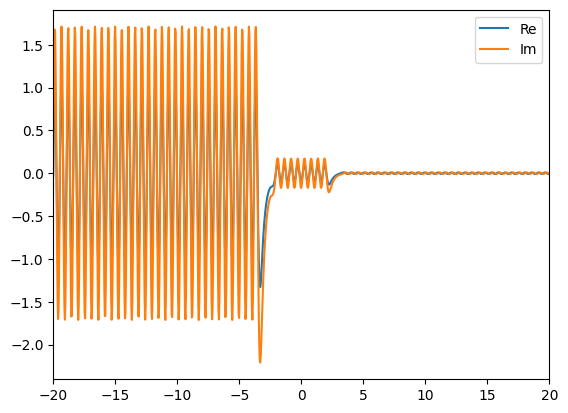

In [21]:
index=2
qp_pk = quasiparticles_pk[index]['state']
qp_mk = quasiparticles_mk[index]['state']
ein = quasiparticles_pk[index]['energy']
print(ein* unit_sys.energy_unit.to('eV').magnitude)

plt.plot(qp_pk['grid'], np.real(qp_pk['value']), label='Re')
plt.plot(qp_pk['grid'], np.imag(qp_pk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

In [22]:
modelpot = get_modelpot()
zeropot = pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(
            uxgrid,
            hbar=unit_sys.hb,
            me=unit_sys.me,
            charge=unit_sys.e0,
            scalarpot=modelpot,
            vectorpot=zeropot
        )

#ein = 1.0 * unit_sys.convert_energy_from('eV')
kin = dispersion.wavenumber(ein)

spk,smk = quat.states_at_given_energy(ein,ham_static)

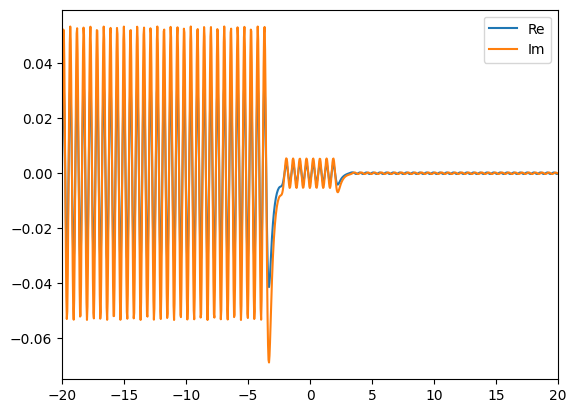

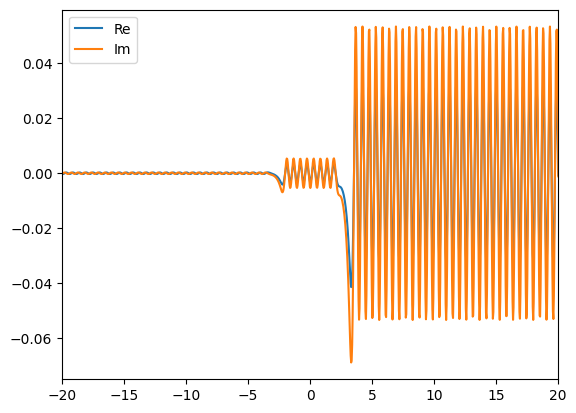

In [23]:
plt.plot(uxgrid, np.real(spk['value']), label='Re')
plt.plot(uxgrid, np.imag(spk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

plt.plot(uxgrid, np.real(smk['value']), label='Re')
plt.plot(uxgrid, np.imag(smk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

In [24]:
alp,blp,arp,brp = quat.amplitudes2(kin,spk)
print(np.abs(alp), np.abs(blp), np.abs(arp), np.abs(brp))

alm,blm,arm,brm = quat.amplitudes2(kin,smk)
print(np.abs(alm), np.abs(blm), np.abs(arm), np.abs(brm))

ain_pk=quat.input_amplitude2(kin,spk)
ain_mk=quat.input_amplitude2(-kin,smk)
print("ain_pk:", ain_pk)
print("ain_mk:", ain_mk)

0.031094923109473274 0.031093746925716252 0.00027045388546952716 2.0996259593443265e-17
2.330645840848587e-17 0.0002704538854693899 0.0310937469257063 0.031094923109472962
ain_pk: (0.030983629771158195-0.0026284842377032797j)
ain_mk: (0.030983629771158896-0.002628484237691387j)


In [25]:
nspk,nsmk = quat.normed_states_at_given_energy(ein,kin,ham_static)

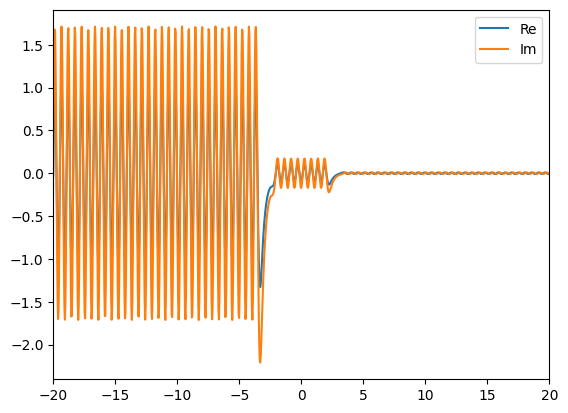

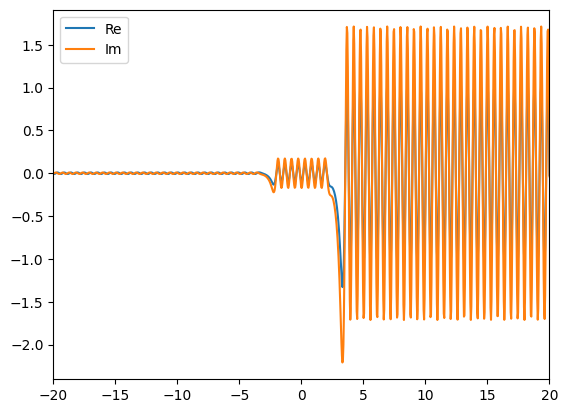

In [26]:
plt.plot(uxgrid, np.real(nspk['value']), label='Re')
plt.plot(uxgrid, np.imag(nspk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

plt.plot(uxgrid, np.real(nsmk['value']), label='Re')
plt.plot(uxgrid, np.imag(nsmk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

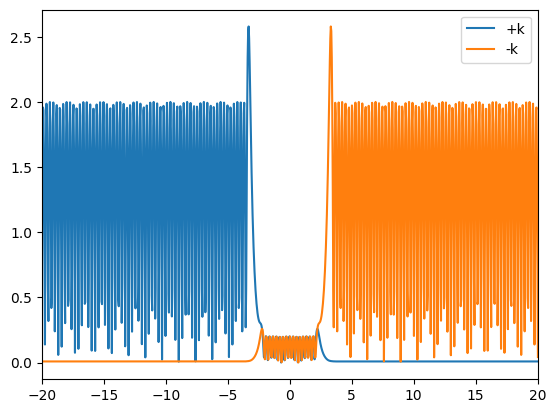

In [27]:
plt.plot(uxgrid, np.abs(nspk['value']), label='+k')
plt.plot(uxgrid, np.abs(nsmk['value']), label='-k')
plt.xlim(-20,20)
plt.legend()
plt.show()

In [28]:
print(type(modelpot(0)))

<class 'numpy.ndarray'>


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


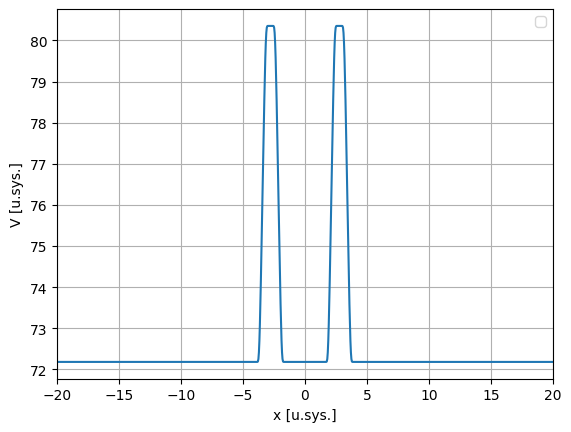

In [29]:
x=uxgrid
y=ham_static.diags[1]
plt.plot(x, y)
plt.xlabel("x [u.sys.]")
plt.ylabel("V [u.sys.]")
plt.xlim(-20, 20)
plt.grid()
plt.legend()
plt.show()

In [30]:
ham0 = ham_static(0)
print(type(ham0), ham0.shape, ham0.dtype)

<class 'scipy.sparse._dia.dia_matrix'> (19384, 19384) complex128
